# Technical‑Debt‑Adjusted Valuation — Scale‑Up Risk Calibration

**Purpose**  
- Quantify how hidden engineering debt and scale‑up complexity distort enterprise value, even when headline EBITDA appears attractive
- The notebook converts engineering reality (rework, validation lag, fragility, and architectural shortcuts) into valuation‑relevant haircuts

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Base Case Valuation Assumptions

In [2]:
BASE_EBITDA = 60_000_000
BASE_ENTRY_MULTIPLE = 9.5
BASE_ENTERPRISE_VALUE = BASE_EBITDA * BASE_ENTRY_MULTIPLE

## 3. Technical Debt Categories

In [3]:
# Scores range from 0 (clean) to 1 (severe)
PROCESS_DEBT = 0.35       # undocumented processes, tribal knowledge
ARCHITECTURAL_DEBT = 0.45 # brittle system design
VALIDATION_DEBT = 0.40    # regulatory / customer requalification exposure
SCALING_DEBT = 0.50       # yield fragility at volume

## 4. Economic Impact Pathways

In [4]:
# Impact mapping coefficients
EBITDA_DRAG = 0.18        # steady‑state margin erosion
CAPEX_OVERRUN = 0.25      # incremental capex required
TIME_TO_SCALE_DELAY = 18 # months

## 5. Integrated Technical Debt Score

In [5]:
technical_debt_score = np.mean([
    PROCESS_DEBT,
    ARCHITECTURAL_DEBT,
    VALIDATION_DEBT,
    SCALING_DEBT
])

technical_debt_score

0.42500000000000004

## 6. EBITDA & Capex Adjustments

In [6]:
adjusted_ebitda = BASE_EBITDA * (1 - technical_debt_score * EBITDA_DRAG)

incremental_capex = BASE_ENTERPRISE_VALUE * CAPEX_OVERRUN * technical_debt_score

adjusted_ebitda, incremental_capex

(55410000.0, 60562500.00000001)

## 7. Time‑to‑Value Discounting

In [7]:
DISCOUNT_RATE = 0.12

value_timing_penalty = BASE_ENTERPRISE_VALUE / ((1 + DISCOUNT_RATE) ** (TIME_TO_SCALE_DELAY / 12))

time_adjusted_value = value_timing_penalty

## 8. Technical‑Debt‑Adjusted Enterprise Value

In [8]:
risk_adjusted_EV = adjusted_ebitda * BASE_ENTRY_MULTIPLE
risk_adjusted_EV -= incremental_capex
risk_adjusted_EV = min(risk_adjusted_EV, time_adjusted_value)

haircut_pct = 1 - (risk_adjusted_EV / BASE_ENTERPRISE_VALUE)

risk_adjusted_EV, haircut_pct

(465832500.0, 0.18274999999999997)

## 9. Sensitivity — Engineering Remediation

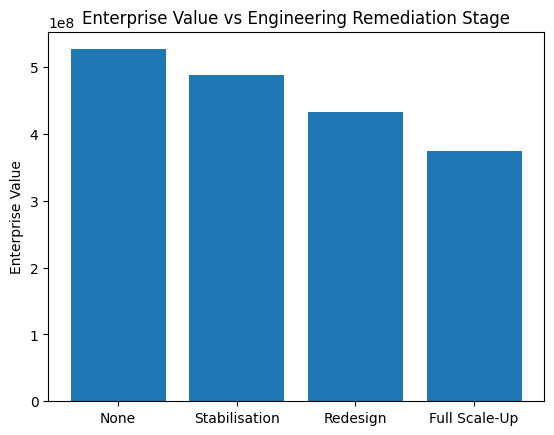

In [11]:
# Remediation stages (realistic, not continuous)
stages = ["None", "Stabilisation", "Redesign", "Full Scale-Up"]

# Fraction of technical debt actually removed at each stage
debt_remaining = {
    "None": 1.00,
    "Stabilisation": 0.85,   # firefighting, documentation
    "Redesign": 0.60,        # architecture & validation work
    "Full Scale-Up": 0.35    # some debt is never fully recoverable
}

# Incremental capex required at each stage (% of base EV)
capex_pct = {
    "None": 0.00,
    "Stabilisation": 0.03,
    "Redesign": 0.08,
    "Full Scale-Up": 0.15
}

# Time delay before EBITDA benefits materialise (months)
delay_months = {
    "None": 0,
    "Stabilisation": 6,
    "Redesign": 15,
    "Full Scale-Up": 24
}

DISCOUNT_RATE = 0.12

EV_results = []

for s in stages:
    td = technical_debt_score * debt_remaining[s]

    # Adjust EBITDA
    ebitda_adj = BASE_EBITDA * (1 - td * EBITDA_DRAG)

    # Capex penalty
    capex = BASE_ENTERPRISE_VALUE * capex_pct[s]

    # Discount for time-to-value
    timing_penalty = 1 / ((1 + DISCOUNT_RATE) ** (delay_months[s] / 12))

    EV = (ebitda_adj * BASE_ENTRY_MULTIPLE - capex) * timing_penalty
    EV_results.append(EV)

EV_results

plt.bar(stages, EV_results)
plt.ylabel("Enterprise Value")
plt.title("Enterprise Value vs Engineering Remediation Stage")
plt.show()

## 10. Deal Interpretation


Headline EBITDA materially overstates value when scale‑up reality is ignored.

This framework surfaces **valuation distortion driven by engineering shortcuts**, not market factors.

The output is designed to support:
- Entry multiple calibration
- Deferred consideration structures
- Capex‑linked earn‑outs
- Go / no‑go decisions on fragile platforms
